# Task 1 — Compreender, auditar e preparar os dados
## 1. Carregamento e limpeza básica

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

DATA_PATH = "Charging_Data_educational.csv"

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

print(df.shape)
df.info()
df.head()

(441077, 47)
<class 'pandas.DataFrame'>
RangeIndex: 441077 entries, 0 to 441076
Data columns (total 47 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   UserID                                        441077 non-null  int64  
 1   Charging Post ID                              441077 non-null  int64  
 2   Location Information                          441077 non-null  str    
 3   District Name                                 441077 non-null  str    
 4   Order creation time                           441077 non-null  str    
 5   Transaction power/kwh                         441077 non-null  float64
 6   Electricity cost/Yuan                         441077 non-null  float64
 7   Service charge/Yuan                           441077 non-null  float64
 8   Transaction Amount/Yuan                       441077 non-null  float64
 9   Actual Payment/Yuan                           

,UserID,Charging Post ID,Location Information,District Name,Order creation time,Transaction power/kwh,Electricity cost/Yuan,Service charge/Yuan,Transaction Amount/Yuan,Actual Payment/Yuan,Start Time,End Time,Payment time,Temperature(℃),Relative Humidity(%),Precipitation(mm),end_cause,electricity_price,tariff_period,post_previous_sessions_1D,post_previous_abnormal_1D,post_previous_abnormal_rate_1D,post_previous_sessions_7D,post_previous_abnormal_7D,post_previous_abnormal_rate_7D,post_previous_sessions_30D,post_previous_abnormal_30D,post_previous_abnormal_rate_30D,post_hours_since_previous_completed_session,post_no_previous_completed_session,post_hours_since_previous_completed_abnormal,post_no_previous_completed_abnormal,is_new_user,user_previous_sessions_30D,user_previous_abnormal_30D,user_previous_abnormal_rate_30D,user_previous_sessions_180D,user_previous_abnormal_180D,user_previous_abnormal_rate_180D,user_previous_sessions_730D,user_previous_abnormal_730D,user_previous_abnormal_rate_730D,user_days_since_previous_completed_session,user_no_previous_completed_session,user_days_since_previous_completed_abnormal,user_no_previous_completed_abnormal,user_active_sessions_at_start
0,11182,24,Shopping Mall,Tongxiang,2019-12-31 21:26:58\t,37.65,33.62,26.62,60.24,60.24,2019-12-31 21:27:03,2020-01-01 05:03:53,2020-01-01 05:03:40\t,3.9,61,0.1,Charging ends normally,0.9014,peak_21_22,0,0,0.2,0,0,0.2,0,0,0.2,NaN,1,NaN,1,1,0,0,0.2,0,0,0.2,0,0,0.2,NaN,1,NaN,1,0
1,27510,67,Government Agency,Xiuzhou,2019-12-31 21:50:58\t,12.03,10.74,8.51,19.25,19.25,2019-12-31 21:50:56,2020-01-01 08:52:56,2020-01-01 08:53:08\t,3.7,62,0.1,Charging ends normally,0.9014,peak_21_22,0,0,0.2,0,0,0.2,0,0,0.2,NaN,1,NaN,1,1,0,0,0.2,0,0,0.2,0,0,0.2,NaN,1,NaN,1,0
2,10877,45,Park B,Tongxiang,2019-12-31 22:19:34\t,44.04,39.33,31.14,70.47,70.47,2019-12-31 22:12:46,2020-01-01 00:36:26,2020-01-01 00:43:11\t,3.9,61,0.1,Charging ends normally,0.3784,off_peak_22_24,0,0,0.2,0,0,0.2,0,0,0.2,NaN,1,NaN,1,1,0,0,0.2,0,0,0.2,0,0,0.2,NaN,1,NaN,1,0
3,11591,26,Shopping Mall,Tongxiang,2019-12-31 22:37:24\t,59.51,53.13,42.08,95.21,95.21,2019-12-31 22:38:55,2020-01-01 19:34:51,2020-01-01 19:33:17\t,3.9,61,0.1,Charging ends normally,0.3784,off_peak_22_24,0,0,0.2,0,0,0.2,0,0,0.2,NaN,1,NaN,1,1,0,0,0.2,0,0,0.2,0,0,0.2,NaN,1,NaN,1,0
4,11425,53,Bus Station,Tongxiang,2019-12-31 23:32:28\t,26.19,23.39,18.52,41.91,41.91,2019-12-31 23:06:44,2020-01-01 07:48:26,2020-01-01 08:14:20\t,3.9,61,0.1,Charging ends normally,0.3784,off_peak_22_24,0,0,0.2,0,0,0.2,0,0,0.2,NaN,1,NaN,1,1,0,0,0.2,0,0,0.2,0,0,0.2,NaN,1,NaN,1,0


In [8]:
# 1) remover espaços/tabs no fim das colunas de texto
for c in df.columns:
    if not pd.api.types.is_numeric_dtype(df[c]):
        df[c] = df[c].str.strip()

# 2) converter colunas temporais
time_cols = ["Order creation time", "Start Time", "End Time", "Payment time"]
for c in time_cols:
    df[c] = pd.to_datetime(df[c])

# 3) todas as colunas (o info() truncou o meio)
print(df.columns.tolist())

# 4) existe o alvo?
print("\nis_Abnormal existe?", "is_Abnormal" in df.columns)

# 5) valores de end_cause
df["end_cause"].value_counts(dropna=False)

['UserID', 'Charging Post ID', 'Location Information', 'District Name', 'Order creation time', 'Transaction power/kwh', 'Electricity cost/Yuan', 'Service charge/Yuan', 'Transaction Amount/Yuan', 'Actual Payment/Yuan', 'Start Time', 'End Time', 'Payment time', 'Temperature(℃)', 'Relative Humidity(%)', 'Precipitation(mm)', 'end_cause', 'electricity_price', 'tariff_period', 'post_previous_sessions_1D', 'post_previous_abnormal_1D', 'post_previous_abnormal_rate_1D', 'post_previous_sessions_7D', 'post_previous_abnormal_7D', 'post_previous_abnormal_rate_7D', 'post_previous_sessions_30D', 'post_previous_abnormal_30D', 'post_previous_abnormal_rate_30D', 'post_hours_since_previous_completed_session', 'post_no_previous_completed_session', 'post_hours_since_previous_completed_abnormal', 'post_no_previous_completed_abnormal', 'is_new_user', 'user_previous_sessions_30D', 'user_previous_abnormal_30D', 'user_previous_abnormal_rate_30D', 'user_previous_sessions_180D', 'user_previous_abnormal_180D', 'us

end_cause
Charging ends normally                                          203201
User stops charging                                             155942
Other faults of the charging pile                                20114
DC Output Fault                                                  14813
Vehicle communications failure                                   13936
Faulty charging connection                                        8539
BMS failure                                                       8170
Failure of non-system control loop components and assemblies      6941
Vehicle charging faults                                           6429
Power conversion unit failure                                     1653
DC switching device failure                                       1058
System communications failure                                      162
AC Input Failure                                                    99
Vehicle Stake Interaction Failure                                  

## 2. Definição da variável-alvo
`is_Abnormal` não existe no ficheiro; é derivada de `end_cause`.
Normal (0): "Charging ends normally", "User stops charging". Anómalo (1): restantes causas.
`end_cause` é pós-sessão (leakage) e não será usada como preditor.

In [9]:
NORMAL_CAUSES = ["Charging ends normally", "User stops charging"]
df["is_Abnormal"] = (~df["end_cause"].isin(NORMAL_CAUSES)).astype(int)

print(df["is_Abnormal"].value_counts())
print("Prevalência:", df["is_Abnormal"].mean().round(4))

(df.groupby("end_cause")["is_Abnormal"]
   .agg(n="size", abnormal="mean")
   .sort_values("n", ascending=False))

is_Abnormal
0    359143
1     81934
Name: count, dtype: int64
Prevalência: 0.1858


,n,abnormal
end_cause,,
Charging ends normally,203201,0.0
User stops charging,155942,0.0
Other faults of the charging pile,20114,1.0
DC Output Fault,14813,1.0
Vehicle communications failure,13936,1.0
Faulty charging connection,8539,1.0
BMS failure,8170,1.0
Failure of non-system control loop components and assemblies,6941,1.0
Vehicle charging faults,6429,1.0


## 3. Qualidade dos dados
Verificações antes de qualquer correção: valores em falta, duplicados, coerência temporal, valores impossíveis e coerência financeira.
As variáveis pós-sessão (energia, custos, pagamentos, `End Time`, `Payment time`) são usadas aqui **apenas para auditoria**, não como preditores.

In [10]:
# --- Valores em falta ---
miss = df.isna().sum()
miss = miss[miss > 0]
print("Colunas com NaN:\n", miss)

# Os NaN das colunas "since previous" coincidem com as flags "no_previous"?
print("\nNaN post_hours_since_previous_completed_session == flag:",
      (df["post_hours_since_previous_completed_session"].isna() == (df["post_no_previous_completed_session"] == 1)).all())
print("NaN post_hours_since_previous_completed_abnormal == flag:",
      (df["post_hours_since_previous_completed_abnormal"].isna() == (df["post_no_previous_completed_abnormal"] == 1)).all())
print("NaN user_days_since_previous_completed_session == flag:",
      (df["user_days_since_previous_completed_session"].isna() == (df["user_no_previous_completed_session"] == 1)).all())
print("NaN user_days_since_previous_completed_abnormal == flag:",
      (df["user_days_since_previous_completed_abnormal"].isna() == (df["user_no_previous_completed_abnormal"] == 1)).all())

# --- Duplicados ---
print("\nDuplicados (linha completa):", df.duplicated().sum())
print("Duplicados (UserID, Charging Post ID, Start Time):",
      df.duplicated(["UserID", "Charging Post ID", "Start Time"]).sum())

# --- Colunas constantes ---
print("Colunas constantes:", [c for c in df.columns if df[c].nunique(dropna=False) <= 1])

Colunas com NaN:
 post_hours_since_previous_completed_session         92
post_hours_since_previous_completed_abnormal       367
user_days_since_previous_completed_session       56647
user_days_since_previous_completed_abnormal     136279
dtype: int64

NaN post_hours_since_previous_completed_session == flag: True
NaN post_hours_since_previous_completed_abnormal == flag: True
NaN user_days_since_previous_completed_session == flag: True
NaN user_days_since_previous_completed_abnormal == flag: True

Duplicados (linha completa): 0
Duplicados (UserID, Charging Post ID, Start Time): 0
Colunas constantes: []


In [11]:
# --- Coerência temporal (minutos) ---
dur = (df["End Time"] - df["Start Time"]).dt.total_seconds() / 60          # duração da sessão
lag = (df["Start Time"] - df["Order creation time"]).dt.total_seconds() / 60  # criação da ordem -> início
pay = (df["Payment time"] - df["End Time"]).dt.total_seconds() / 60        # fim -> pagamento

print("Fim < início:", (dur < 0).sum(), "| duração == 0:", (dur == 0).sum())
print("Início < criação da ordem:", (lag < 0).sum())
print("Pagamento < fim:", (pay < 0).sum())

print("\nDuração (min):")
print(dur.describe(percentiles=[.01, .5, .99]).round(2))
print("\nCriação -> início (min):")
print(lag.describe(percentiles=[.01, .5, .99]).round(2))

# --- Valores impossíveis nas numéricas ---
num_cols = df.select_dtypes("number").columns.drop("is_Abnormal")
neg = (df[num_cols] < 0).sum()
print("\nColunas com valores negativos:\n", neg[neg > 0])

# --- Coerência financeira (auditoria) ---
print("\n|custo + serviço - montante| > 0.05:",
      ((df["Electricity cost/Yuan"] + df["Service charge/Yuan"] - df["Transaction Amount/Yuan"]).abs() > 0.05).sum())
print("Pago > montante:", (df["Actual Payment/Yuan"] > df["Transaction Amount/Yuan"] + 0.05).sum())
print("kWh <= 0:", (df["Transaction power/kwh"] <= 0).sum(), "| montante <= 0:", (df["Transaction Amount/Yuan"] <= 0).sum())

Fim < início: 0 | duração == 0: 5
Início < criação da ordem: 248588
Pagamento < fim: 87202

Duração (min):
count    441077.00
mean         54.70
std          94.68
min           0.00
1%            0.43
50%          33.28
99%         557.60
max        1439.13
dtype: float64

Criação -> início (min):
count    441077.00
mean         -0.61
std           9.85
min       -4650.82
1%           -5.78
50%          -0.10
99%           2.00
max           6.02
dtype: float64

Colunas com valores negativos:
 Temperature(℃)    2052
dtype: int64

|custo + serviço - montante| > 0.05: 0
Pago > montante: 0
kWh <= 0: 54621 | montante <= 0: 54628


### 3.1 Investigação de anomalias detetadas
Antes de qualquer correção: (a) sessões com energia ≤ 0, (b) incoerência `Order creation time` vs `Start Time`, (c) temperaturas negativas, (d) duração e possível corte às 24 h.

In [12]:
dur = (df["End Time"] - df["Start Time"]).dt.total_seconds() / 60
lag = (df["Start Time"] - df["Order creation time"]).dt.total_seconds() / 60

# (a) energia <= 0 e relação com o alvo
zero = df["Transaction power/kwh"] <= 0
print("(a) kWh<=0 vs alvo:")
print(df.groupby(zero)["is_Abnormal"].agg(n="size", abnormal="mean").round(3))
print("\nend_cause nas sessões com kWh<=0 (%):")
print(df.loc[zero, "end_cause"].value_counts(normalize=True).head(6).round(3))

# (b) criação da ordem vs início
print("\n(b) |lag| > 10 min:", (lag.abs() > 10).sum(), "| lag < -60 min:", (lag < -60).sum())
print(df.loc[lag < -60, ["Order creation time", "Start Time", "End Time", "is_Abnormal"]].head())
print("Taxa de anómalas lag<0 vs lag>=0:", df.groupby(lag < 0)["is_Abnormal"].mean().round(3).to_dict())

# (c) temperaturas negativas
print("\n(c) Temperatura:", df["Temperature(℃)"].min(), "→", df["Temperature(℃)"].max())
print(df.loc[df["Temperature(℃)"] < 0, "Start Time"].dt.to_period("M").value_counts().sort_index())

# (d) duração: corte às 24h e relação com o alvo
print("\n(d) duração >= 1439 min:", (dur >= 1439).sum(), "| duração < 1 min:", (dur < 1).sum())
bins = [-1, 1, 5, 30, 120, 600, 1440]
print(df.groupby(pd.cut(dur, bins))["is_Abnormal"].agg(n="size", abnormal="mean").round(3))

(a) kWh<=0 vs alvo:
                            n  abnormal
Transaction power/kwh                  
False                  386456     0.094
True                    54621     0.834

end_cause nas sessões com kWh<=0 (%):
end_cause
Other faults of the charging pile                               0.250
Vehicle communications failure                                  0.236
User stops charging                                             0.142
Failure of non-system control loop components and assemblies    0.104
Vehicle charging faults                                         0.099
Faulty charging connection                                      0.049
Name: proportion, dtype: float64

(b) |lag| > 10 min: 2130 | lag < -60 min: 205
     Order creation time          Start Time            End Time  is_Abnormal
1988 2020-01-09 10:05:13 2020-01-09 09:03:24 2020-01-09 10:05:05            0
4797 2020-01-20 10:45:51 2020-01-20 09:05:38 2020-01-20 10:46:28            0
6911 2020-02-21 20:01:50 2020-02-21 1

### 3.2 Decisões de qualidade
Nenhuma observação removida. Variáveis excluídas como preditores: pós-sessão (`end_cause`, `End Time`, `Payment time`, energia, custos, montantes, pagamento) e `Order creation time` (timestamp inconsistente com o início).
Sessões com kWh<=0 e durações curtas são mantidas: concentram sessões anómalas.
## 4. Análise temporal

Período: 2019-12-31 21:27:03 → 2021-12-31 23:52:14


,n,abn_rate,users,posts,new_user_share,temp_mean,temp_min
ym,,,,,,,
2019-12,17,0.294,16,17,0.941,3.841,3.7
2020-01,6217,0.250,1963,92,0.314,7.092,3.9
2020-02,1391,0.263,516,83,0.237,10.229,2.8
2020-03,6392,0.248,1797,92,0.209,12.749,6.0
2020-04,11136,0.221,2622,92,0.155,15.978,10.8
2020-05,15033,0.192,3153,92,0.124,23.003,18.9
2020-06,17513,0.160,3185,91,0.097,25.958,21.3
2020-07,22032,0.182,3704,92,0.088,26.980,22.2
2020-08,25562,0.201,4733,92,0.104,30.675,25.3


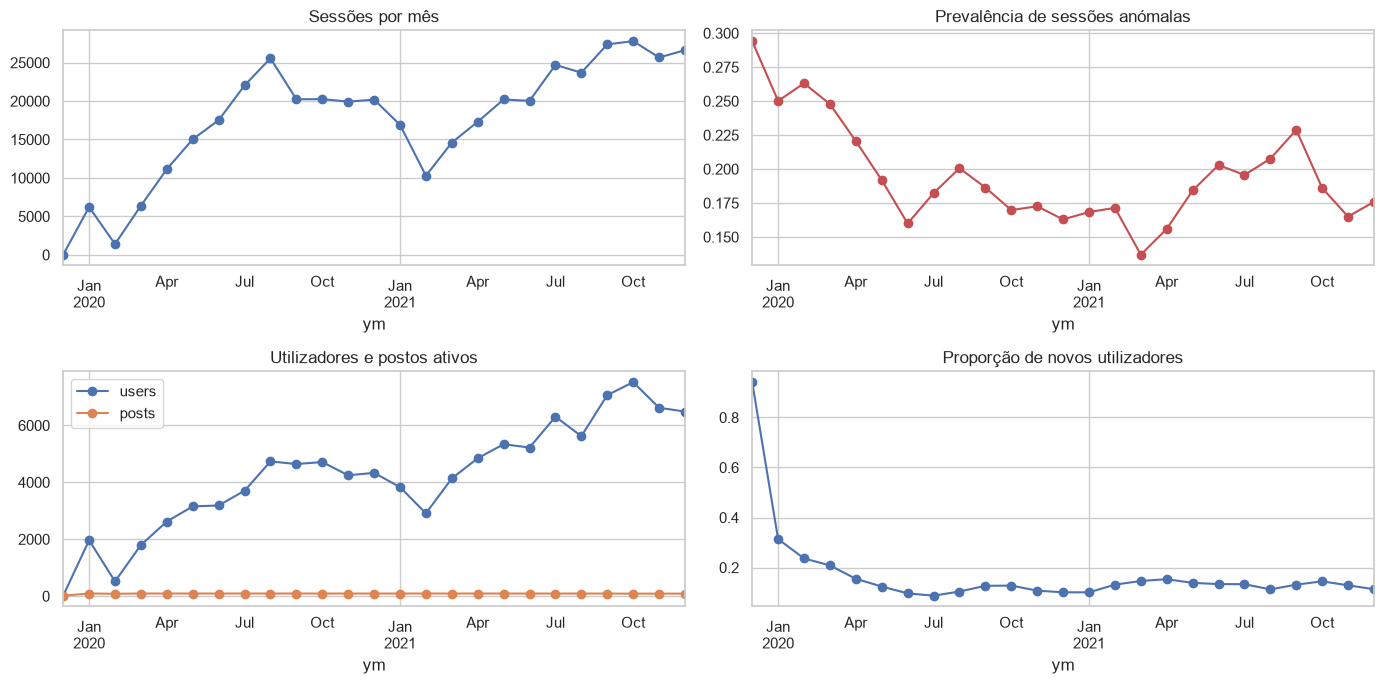

In [13]:
# ordenar cronologicamente pelo início da sessão (referência da predição)
df = df.sort_values("Start Time").reset_index(drop=True)
df["ym"] = df["Start Time"].dt.to_period("M")

print("Período:", df["Start Time"].min(), "→", df["Start Time"].max())

m = df.groupby("ym").agg(
    n=("is_Abnormal", "size"),
    abn_rate=("is_Abnormal", "mean"),
    users=("UserID", "nunique"),
    posts=("Charging Post ID", "nunique"),
    new_user_share=("is_new_user", "mean"),
    temp_mean=("Temperature(℃)", "mean"),
    temp_min=("Temperature(℃)", "min"),
)
display(m.round(3))

fig, ax = plt.subplots(2, 2, figsize=(14, 7))
m["n"].plot(ax=ax[0, 0], marker="o", title="Sessões por mês")
m["abn_rate"].plot(ax=ax[0, 1], marker="o", color="C3", title="Prevalência de sessões anómalas")
m[["users", "posts"]].plot(ax=ax[1, 0], marker="o", title="Utilizadores e postos ativos")
m["new_user_share"].plot(ax=ax[1, 1], marker="o", title="Proporção de novos utilizadores")
plt.tight_layout()
plt.show()

### 4.1 Estabilidade temporal dos preditores e cobertura do histórico
Evolução mensal da cobertura do histórico (arranque a frio) e de preditores disponíveis no início da sessão, e relação sazonal entre temperatura e prevalência.

,post_sem_hist,user_sem_hist,user_sem_hist_abn,post_sessions_7D,post_abn_rate_30D,user_sessions_30D,user_abn_rate_730D,active_at_start,price
ym,,,,,,,,,
2019-12,1.000,1.000,1.000,0.000,0.200,0.000,0.200,0.059,0.440
2020-01,0.012,0.321,0.551,25.170,0.243,13.784,0.231,0.079,0.769
2020-02,0.000,0.238,0.421,8.182,0.231,19.133,0.252,0.067,0.785
2020-03,0.000,0.212,0.426,26.986,0.257,26.397,0.241,0.089,0.784
2020-04,0.000,0.156,0.363,46.470,0.231,45.716,0.225,0.081,0.771
2020-05,0.000,0.126,0.311,57.276,0.195,79.493,0.208,0.202,0.763
2020-06,0.000,0.098,0.270,61.535,0.175,309.163,0.195,0.710,0.719
2020-07,0.000,0.088,0.240,68.958,0.168,168.601,0.189,0.216,0.717
2020-08,0.000,0.105,0.236,84.633,0.199,36.145,0.200,0.020,0.742


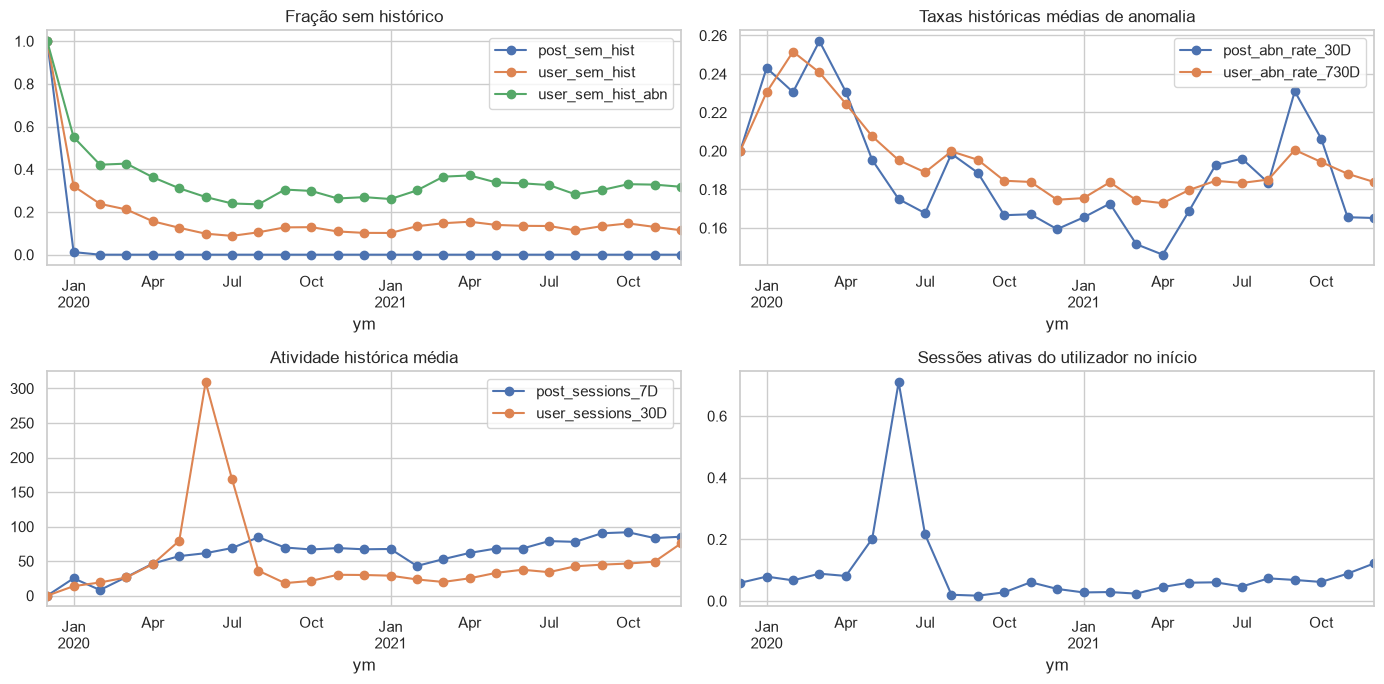

Correlação (temp_mean, abn_rate): 0.037
Correlação (n, abn_rate): -0.452


In [14]:
cov = df.groupby("ym").agg(
    post_sem_hist=("post_no_previous_completed_session", "mean"),
    user_sem_hist=("user_no_previous_completed_session", "mean"),
    user_sem_hist_abn=("user_no_previous_completed_abnormal", "mean"),
    post_sessions_7D=("post_previous_sessions_7D", "mean"),
    post_abn_rate_30D=("post_previous_abnormal_rate_30D", "mean"),
    user_sessions_30D=("user_previous_sessions_30D", "mean"),
    user_abn_rate_730D=("user_previous_abnormal_rate_730D", "mean"),
    active_at_start=("user_active_sessions_at_start", "mean"),
    price=("electricity_price", "mean"),
)
display(cov.round(3))

fig, ax = plt.subplots(2, 2, figsize=(14, 7))
cov[["post_sem_hist", "user_sem_hist", "user_sem_hist_abn"]].plot(ax=ax[0, 0], marker="o", title="Fração sem histórico")
cov[["post_abn_rate_30D", "user_abn_rate_730D"]].plot(ax=ax[0, 1], marker="o", title="Taxas históricas médias de anomalia")
cov[["post_sessions_7D", "user_sessions_30D"]].plot(ax=ax[1, 0], marker="o", title="Atividade histórica média")
cov["active_at_start"].plot(ax=ax[1, 1], marker="o", title="Sessões ativas do utilizador no início")
plt.tight_layout()
plt.show()

# sazonalidade: temperatura média mensal vs prevalência (sem dez/2019, só 17 sessões)
mm = m.iloc[1:]
print("Correlação (temp_mean, abn_rate):", round(mm["abn_rate"].corr(mm["temp_mean"]), 3))
print("Correlação (n, abn_rate):", round(mm["n"].corr(mm["abn_rate"]), 3))

### 4.2 Investigação do pico de atividade de utilizadores (mai–jul/2020)
A média mensal de `user_previous_sessions_30D` e `user_active_sessions_at_start` dispara em mai–jul/2020. Verificar se é causado por poucas contas muito ativas e como se relacionam com o alvo.

In [15]:
# perfil por utilizador
uc = df.groupby("UserID").agg(
    n=("is_Abnormal", "size"),
    abn=("is_Abnormal", "mean"),
    first=("Start Time", "min"),
    last=("Start Time", "max"),
    posts=("Charging Post ID", "nunique"),
)
uc["share"] = uc["n"] / len(df)
print("Utilizadores:", len(uc), "| mediana sessões:", uc["n"].median(), "| p99:", uc["n"].quantile(.99))
print("Quota das sessões dos top 10 utilizadores:", uc["share"].nlargest(10).sum().round(4))
display(uc.sort_values("n", ascending=False).head(10).round(3))

# sessões mensais dos 5 utilizadores mais ativos
top_users = uc["n"].nlargest(5).index
display(df[df["UserID"].isin(top_users)].groupby(["ym", "UserID"]).size().unstack(fill_value=0))

# quem tem o máximo de histórico/concorrência no pico?
pk = df[df["ym"].between("2020-05", "2020-07")]
display(pk.nlargest(5, "user_previous_sessions_30D")[
    ["UserID", "Start Time", "user_previous_sessions_30D", "user_active_sessions_at_start", "is_Abnormal"]])

# concorrência vs alvo
bins = [-1, 0, 1, 2, 5, 1000]
print(df.groupby(pd.cut(df["user_active_sessions_at_start"], bins))["is_Abnormal"]
        .agg(n="size", abnormal="mean").round(3))

Utilizadores: 56115 | mediana sessões: 2.0 | p99: 126.0
Quota das sessões dos top 10 utilizadores: 0.0655


C:\Users\inesm\AppData\Local\Temp\ipykernel_21280\2377055656.py:12: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(uc.sort_values("n", ascending=False).head(10).round(3))


,n,abn,first,last,posts,share
UserID,,,,,,
39,14584,0.158,2020-01-01 03:05:53,2021-12-31 21:38:35,92,0.033
23,6748,0.145,2020-09-18 13:34:14,2021-12-31 22:22:56,92,0.015
1087,1094,0.174,2020-01-01 00:12:32,2021-12-31 10:25:10,48,0.002
1457,995,0.154,2020-03-30 18:56:36,2021-12-31 10:25:47,58,0.002
7841,994,0.121,2020-04-16 15:42:52,2021-12-16 07:03:51,42,0.002
520,983,0.208,2020-09-18 03:31:53,2021-12-31 22:38:01,48,0.002
604,900,0.359,2020-05-18 21:00:57,2021-12-31 07:51:03,30,0.002
4990,895,0.082,2020-03-07 19:04:22,2021-12-30 15:49:49,18,0.002
3679,842,0.163,2020-03-10 09:53:29,2021-12-29 21:43:16,54,0.002


UserID,23,39,1087,1457,7841
ym,,,,,
2020-01,0,327,13,0,0
2020-02,0,129,0,0,0
2020-03,0,447,0,3,0
2020-04,0,663,34,55,31
2020-05,0,1172,76,42,68
2020-06,0,2597,68,48,71
2020-07,0,1339,61,58,80
2020-08,0,267,66,70,73
2020-09,53,136,78,12,51


,UserID,Start Time,user_previous_sessions_30D,user_active_sessions_at_start,is_Abnormal
57478,39,2020-06-30 17:08:34,2605,3,0
57467,39,2020-06-30 16:49:30,2603,5,0
57508,39,2020-06-30 18:18:55,2603,0,0
57512,39,2020-06-30 18:24:28,2603,1,0
57465,39,2020-06-30 16:46:51,2602,5,0


                                    n  abnormal
user_active_sessions_at_start                  
(-1, 0]                        420500     0.185
(0, 1]                          11718     0.238
(1, 2]                           3799     0.165
(2, 5]                           3907     0.139
(5, 1000]                        1153     0.138
